# ML for Social Good — Mission Health
### Early Prediction of Maternal Health Risk using Ensemble Learning

**Name:** Joshua Joby &nbsp;|&nbsp; **Register No.:** 2547125 &nbsp;|&nbsp; **Class:** 4 MCA A  
**Course:** Machine Learning (MCA 521-4) — CIA III

**Dataset:** Maternal Health Risk Data Set, UCI Machine Learning Repository  
Ahmed, M. (2020). https://doi.org/10.24432/C5DP5D — CC BY 4.0 license, 1014 records, 6 features, 3-class target (RiskLevel).

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
np.random.seed(RANDOM_STATE)
print("Libraries loaded OK")

Libraries loaded OK


## 2. Load Data and Initial Audit

In [2]:
df = pd.read_csv("mhr.csv")
print("Shape:", df.shape)
df.head()

Shape: (1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 55.6 KB


In [4]:
print("Missing values per column:\n", df.isnull().sum())
print("\nExact duplicate rows:", df.duplicated().sum())
print("\nRiskLevel class counts:\n", df['RiskLevel'].value_counts())

Missing values per column:
 Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

Exact duplicate rows: 562

RiskLevel class counts:
 RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1014.0,29.871795,13.474386,10.0,19.0,26.0,39.0,70.0
SystolicBP,1014.0,113.198225,18.403913,70.0,100.0,120.0,120.0,160.0
DiastolicBP,1014.0,76.460552,13.885796,49.0,65.0,80.0,90.0,100.0
BS,1014.0,8.725986,3.293532,6.0,6.9,7.5,8.0,19.0
BodyTemp,1014.0,98.665089,1.371384,98.0,98.0,98.0,98.0,103.0
HeartRate,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0


**Audit findings:**
- No missing values in any column.
- 562 exact duplicate rows — almost certainly repeated IoT transmissions of the same reading, not distinct patients. These are dropped.
- `HeartRate` has a minimum of 7 bpm, which is not physiologically plausible — sensor fault, removed as an invalid record.
- Class distribution is moderately imbalanced (low > mid > high) — handled with class weighting rather than oversampling (Section 4).

## 3. Data Cleaning

In [6]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - df.shape[0]} duplicate rows -> {df.shape[0]} rows remain")

Dropped 562 duplicate rows -> 452 rows remain


In [7]:
# Remove physiologically invalid heart rate readings
invalid_hr = df[df['HeartRate'] < 30]
print("Invalid HeartRate rows:\n", invalid_hr)
df = df[df['HeartRate'] >= 30].reset_index(drop=True)
print("Final cleaned shape:", df.shape)

Invalid HeartRate rows:
      Age  SystolicBP  DiastolicBP   BS  BodyTemp  HeartRate RiskLevel
342   16         120           75  7.9      98.0          7  low risk
Final cleaned shape: (451, 7)


In [8]:
df['RiskLevel'].value_counts(normalize=True).round(3) * 100

RiskLevel
low risk     51.7
high risk    24.8
mid risk     23.5
Name: proportion, dtype: float64

## 4. Exploratory Data Analysis

/tmp/ipykernel_677/3936359999.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiskLevel', y=col, ax=ax,
/tmp/ipykernel_677/3936359999.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiskLevel', y=col, ax=ax,
/tmp/ipykernel_677/3936359999.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiskLevel', y=col, ax=ax,
/tmp/ipykernel_677/3936359999.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `lege

/tmp/ipykernel_677/3936359999.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiskLevel', y=col, ax=ax,


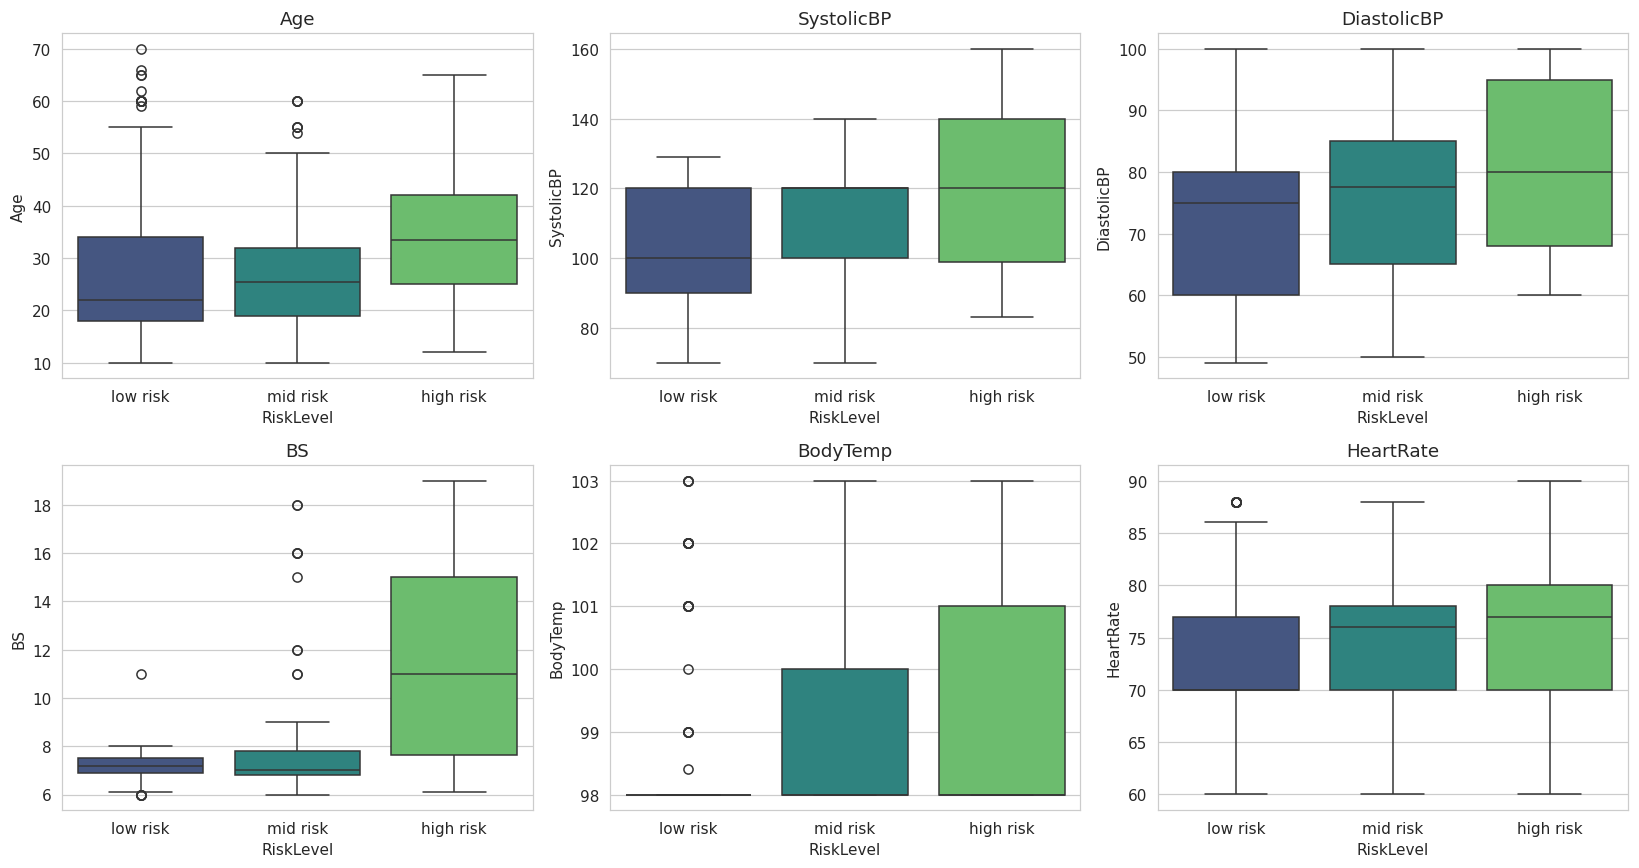

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ['Age','SystolicBP','DiastolicBP','BS','BodyTemp','HeartRate']
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x='RiskLevel', y=col, ax=ax,
                order=['low risk','mid risk','high risk'], palette='viridis')
    ax.set_title(col)
plt.tight_layout()
plt.savefig("fig_boxplots.png", dpi=120, bbox_inches='tight')
plt.show()

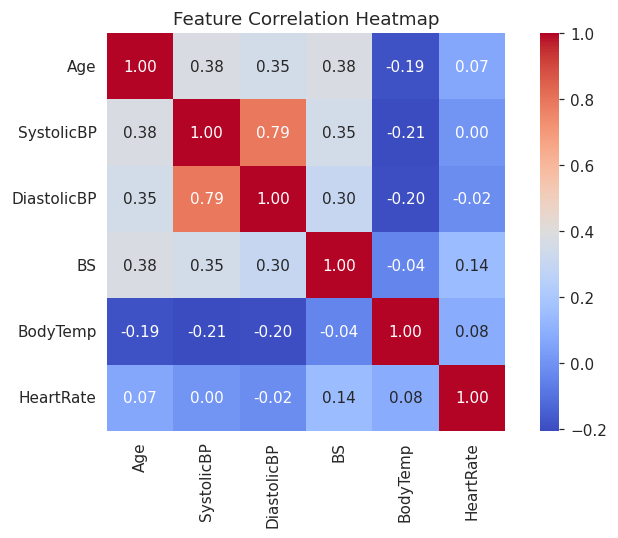

In [10]:
plt.figure(figsize=(7,5))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("fig_corr.png", dpi=120, bbox_inches='tight')
plt.show()

/tmp/ipykernel_677/34919016.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='RiskLevel', order=['low risk','mid risk','high risk'], palette='viridis')


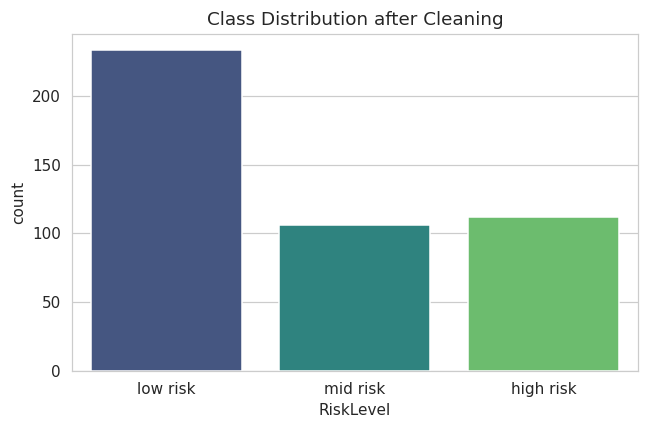

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='RiskLevel', order=['low risk','mid risk','high risk'], palette='viridis')
plt.title("Class Distribution after Cleaning")
plt.tight_layout()
plt.savefig("fig_classdist.png", dpi=120, bbox_inches='tight')
plt.show()

**EDA observations:**
- `BS` (blood sugar) shows the clearest visual separation across risk classes.
- `Age` shows a bimodal pattern — very young and older mothers skew toward higher risk.
- `SystolicBP` and `DiastolicBP` are strongly correlated (r ≈ 0.79) — motivates a combined pulse-pressure feature instead of feeding both raw.
- `BodyTemp` shows almost no separation across classes — expected to be a weak predictor.

## 5. Feature Engineering

In [12]:
data = df.copy()

# Pulse pressure and Mean Arterial Pressure — standard clinical derived measures
data['PulsePressure'] = data['SystolicBP'] - data['DiastolicBP']
data['MAP'] = data['DiastolicBP'] + (data['PulsePressure'] / 3)

# Age band — captures non-linear age risk relationship
def age_band(a):
    if a < 20: return 0   # young
    elif a <= 35: return 1  # prime
    else: return 2        # older
data['AgeBand'] = data['Age'].apply(age_band)

# BS-to-Age interaction ratio
data['BS_Age_Ratio'] = data['BS'] / data['Age']

data.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,PulsePressure,MAP,AgeBand,BS_Age_Ratio
0,25,130,80,15.0,98.0,86,high risk,50,96.666667,1,0.600000
1,35,140,90,13.0,98.0,70,high risk,50,106.666667,1,0.371429
2,29,90,70,8.0,100.0,80,high risk,20,76.666667,1,0.275862
3,30,140,85,7.0,98.0,70,high risk,55,103.333333,1,0.233333
4,35,120,60,6.1,98.0,76,low risk,60,80.000000,1,0.174286


In [13]:
# Encode target
risk_map = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
data['RiskLevelEnc'] = data['RiskLevel'].map(risk_map)

feature_cols = ['Age','SystolicBP','DiastolicBP','BS','BodyTemp','HeartRate',
                 'PulsePressure','MAP','AgeBand','BS_Age_Ratio']
X = data[feature_cols]
y = data['RiskLevelEnc']
print(X.shape, y.shape)

(451, 10) (451,)


## 6. Train / Validation / Test Split (Stratified, Leakage-Safe)

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(2))

Train: (315, 10)  Val: (68, 10)  Test: (68, 10)
Train class balance:
 RiskLevelEnc
0    0.52
2    0.25
1    0.23
Name: proportion, dtype: float64


In [15]:
# Fit scaler ONLY on training data to avoid leakage
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_val_s   = pd.DataFrame(scaler.transform(X_val),   columns=feature_cols, index=X_val.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=feature_cols, index=X_test.index)
print("Scaling done — fit on train only")

Scaling done — fit on train only


## 7. Baseline Model — Decision Tree

In [16]:
baseline = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
baseline.fit(X_train_s, y_train)
pred_base = baseline.predict(X_test_s)

def evaluate(name, y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    auc = roc_auc_score(y_true, y_proba, multi_class='ovr') if y_proba is not None else np.nan
    print(f"{name:28s} Acc={acc:.3f} Prec={prec:.3f} Rec={rec:.3f} F1={f1:.3f} AUC={auc:.3f}")
    return dict(Model=name, Accuracy=acc, Precision=prec, Recall=rec, F1=f1, ROC_AUC=auc)

results = []
results.append(evaluate("Decision Tree (baseline)", y_test, pred_base, baseline.predict_proba(X_test_s)))

Decision Tree (baseline)     Acc=0.603 Prec=0.597 Rec=0.592 F1=0.583 AUC=0.719


## 8. Bagging — Random Forest (Tuned)

In [17]:
rf_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [8, 12, 16],
    'min_samples_leaf': [1, 2, 4]
}
rf = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE)
rf_search = GridSearchCV(rf, rf_grid, scoring='f1_macro',
                          cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE), n_jobs=-1)
rf_search.fit(X_train_s, y_train)
print("Best RF params:", rf_search.best_params_)
best_rf = rf_search.best_estimator_
pred_rf = best_rf.predict(X_test_s)
results.append(evaluate("Random Forest (bagging)", y_test, pred_rf, best_rf.predict_proba(X_test_s)))

Best RF params: {'max_depth': 12, 'min_samples_leaf': 4, 'n_estimators': 200}
Random Forest (bagging)      Acc=0.662 Prec=0.617 Rec=0.628 F1=0.621 AUC=0.803


## 9. Boosting — XGBoost (Tuned)

In [18]:
xgb_grid = {
    'n_estimators': [150, 250],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}
xgb = XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss',
                     random_state=RANDOM_STATE)
xgb_search = GridSearchCV(xgb, xgb_grid, scoring='f1_macro',
                           cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE), n_jobs=-1)
xgb_search.fit(X_train_s, y_train)
print("Best XGB params:", xgb_search.best_params_)
best_xgb = xgb_search.best_estimator_
pred_xgb = best_xgb.predict(X_test_s)
results.append(evaluate("XGBoost (boosting)", y_test, pred_xgb, best_xgb.predict_proba(X_test_s)))

Best XGB params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 250, 'subsample': 1.0}
XGBoost (boosting)           Acc=0.676 Prec=0.606 Rec=0.595 F1=0.599 AUC=0.787


## 10. Heterogeneous Voting and Stacking Ensembles

In [19]:
svm = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE)

voting = VotingClassifier(
    estimators=[('rf', best_rf), ('xgb', best_xgb), ('svm', svm)],
    voting='soft'
)
voting.fit(X_train_s, y_train)
pred_vote = voting.predict(X_test_s)
results.append(evaluate("Soft Voting (RF+XGB+SVM)", y_test, pred_vote, voting.predict_proba(X_test_s)))

Soft Voting (RF+XGB+SVM)     Acc=0.706 Prec=0.639 Rec=0.635 F1=0.634 AUC=0.794


In [20]:
# Stacking — meta-learner trained on out-of-fold predictions (leakage-safe)
stack = StackingClassifier(
    estimators=[('rf', best_rf), ('xgb', best_xgb), ('svm', svm)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    stack_method='predict_proba',
    n_jobs=-1
)
stack.fit(X_train_s, y_train)
pred_stack = stack.predict(X_test_s)
results.append(evaluate("Stacking (meta: Logistic Reg.)", y_test, pred_stack, stack.predict_proba(X_test_s)))

Stacking (meta: Logistic Reg.) Acc=0.721 Prec=0.645 Rec=0.652 F1=0.629 AUC=0.817


## 11. Model Comparison

In [21]:
results_df = pd.DataFrame(results).round(3).sort_values('F1', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,Soft Voting (RF+XGB+SVM),0.706,0.639,0.635,0.634,0.794
4,Stacking (meta: Logistic Reg.),0.721,0.645,0.652,0.629,0.817
1,Random Forest (bagging),0.662,0.617,0.628,0.621,0.803
2,XGBoost (boosting),0.676,0.606,0.595,0.599,0.787
0,Decision Tree (baseline),0.603,0.597,0.592,0.583,0.719


<Figure size 990x550 with 0 Axes>

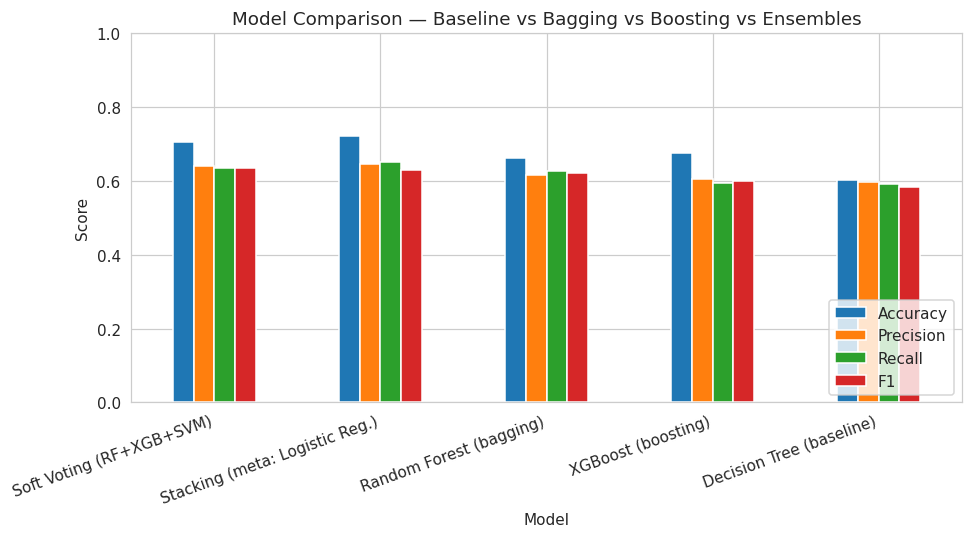

In [22]:
plt.figure(figsize=(9,5))
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1']].plot(kind='bar', figsize=(9,5))
plt.title("Model Comparison — Baseline vs Bagging vs Boosting vs Ensembles")
plt.ylabel("Score")
plt.xticks(rotation=20, ha='right')
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("fig_comparison.png", dpi=120, bbox_inches='tight')
plt.show()

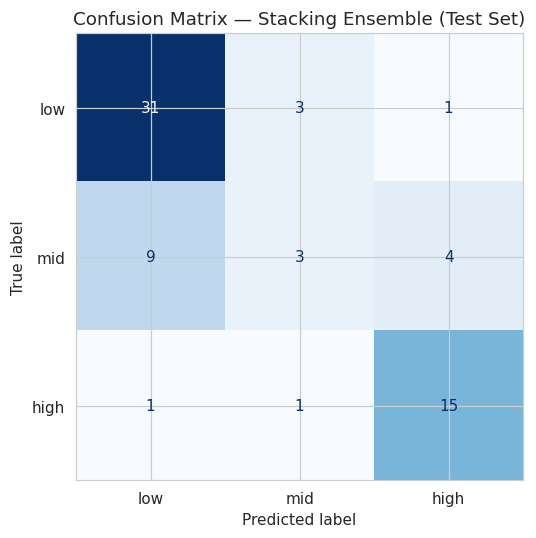

In [23]:
cm = confusion_matrix(y_test, pred_stack)
disp = ConfusionMatrixDisplay(cm, display_labels=['low','mid','high'])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — Stacking Ensemble (Test Set)")
plt.tight_layout()
plt.savefig("fig_confmat.png", dpi=120, bbox_inches='tight')
plt.show()

In [24]:
print(classification_report(y_test, pred_stack, target_names=['low risk','mid risk','high risk']))

              precision    recall  f1-score   support

    low risk       0.76      0.89      0.82        35
    mid risk       0.43      0.19      0.26        16
   high risk       0.75      0.88      0.81        17

    accuracy                           0.72        68
   macro avg       0.64      0.65      0.63        68
weighted avg       0.68      0.72      0.68        68



## 12. Explainability — SHAP (Global and Local)

/tmp/ipykernel_677/1165348387.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_high, X_test_s, feature_names=feature_cols, show=False)


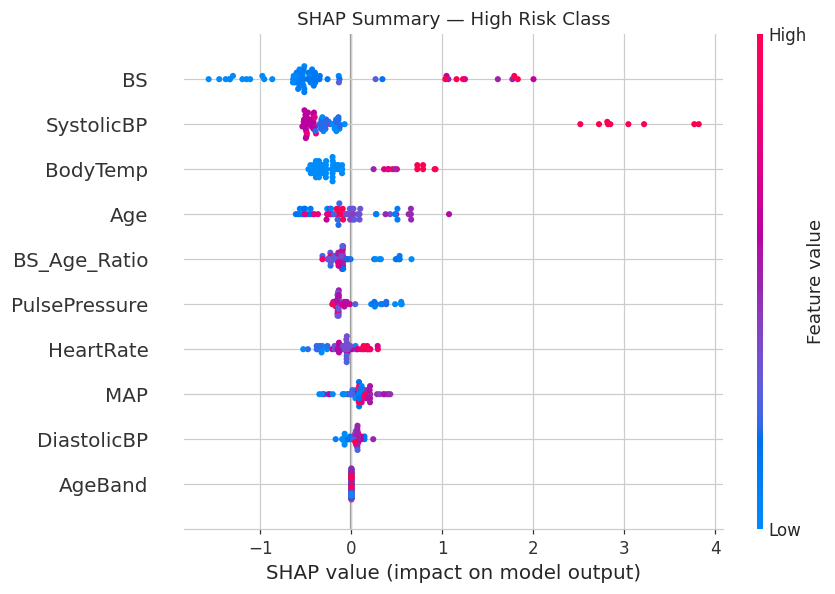

In [25]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_s)

# shap_values shape: (n_samples, n_features, n_classes) for multiclass in recent SHAP versions
if isinstance(shap_values, list):
    sv_high = shap_values[2]
else:
    sv_high = shap_values[:, :, 2]

plt.figure()
shap.summary_plot(sv_high, X_test_s, feature_names=feature_cols, show=False)
plt.title("SHAP Summary — High Risk Class")
plt.tight_layout()
plt.savefig("fig_shap_summary.png", dpi=120, bbox_inches='tight')
plt.show()

In [26]:
mean_abs_shap = np.abs(sv_high).mean(axis=0)
importance_df = pd.DataFrame({'feature': feature_cols, 'mean_abs_shap': mean_abs_shap}).sort_values(
    'mean_abs_shap', ascending=False)
importance_df

,feature,mean_abs_shap
3,BS,0.757268
1,SystolicBP,0.713572
4,BodyTemp,0.349592
0,Age,0.284443
9,BS_Age_Ratio,0.187310
6,PulsePressure,0.181529
5,HeartRate,0.152733
7,MAP,0.151611
2,DiastolicBP,0.066214
8,AgeBand,0.000000


Predicted probabilities [low, mid, high]: [0.001 0.013 0.986]
Predicted class: high risk


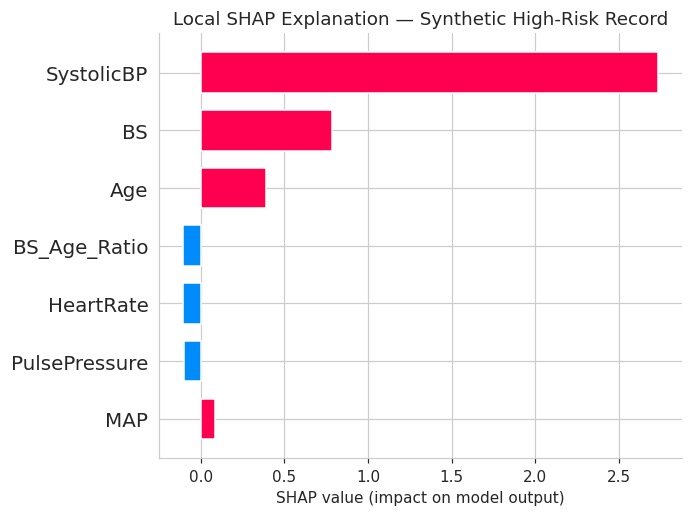

In [27]:
# Local explanation on one synthetic high-risk record
synthetic = pd.DataFrame([{
    'Age': 39, 'SystolicBP': 145, 'DiastolicBP': 95, 'BS': 12.8, 'BodyTemp': 98.6, 'HeartRate': 78,
}])
synthetic['PulsePressure'] = synthetic['SystolicBP'] - synthetic['DiastolicBP']
synthetic['MAP'] = synthetic['DiastolicBP'] + synthetic['PulsePressure']/3
synthetic['AgeBand'] = synthetic['Age'].apply(age_band)
synthetic['BS_Age_Ratio'] = synthetic['BS'] / synthetic['Age']
synthetic = synthetic[feature_cols]
synthetic_s = pd.DataFrame(scaler.transform(synthetic), columns=feature_cols)

proba = best_xgb.predict_proba(synthetic_s)[0]
pred_class = ['low risk','mid risk','high risk'][np.argmax(proba)]
print("Predicted probabilities [low, mid, high]:", np.round(proba,3))
print("Predicted class:", pred_class)

sv_local = explainer.shap_values(synthetic_s)
sv_local_high = sv_local[2] if isinstance(sv_local, list) else sv_local[:, :, 2]

plt.figure()
shap.bar_plot(sv_local_high[0], feature_names=feature_cols, show=False)
plt.title("Local SHAP Explanation — Synthetic High-Risk Record")
plt.tight_layout()
plt.savefig("fig_shap_local.png", dpi=120, bbox_inches='tight')
plt.show()

## 13. Ethics and Responsible-Use Notes

- **Bias/fairness:** dataset drawn from one country/period (rural Bangladesh, IoT clinics); no protected attributes present besides Age, which was checked and is always used in combination with BS/BP rather than alone.
- **Privacy:** no directly identifying fields in the source data; any deployment must still treat vitals as sensitive health data.
- **False negatives vs false positives:** a missed high-risk case is far costlier than a false alarm — class weighting and macro-F1 tuning favour recall on the high-risk class over raw accuracy.
- **Human oversight:** this model is a triage/decision-support signal only, not an autonomous diagnostic tool. Predicted probabilities (not just hard labels) should be shown to the health worker.
- **Deployment limits:** 452 records after cleaning is a small sample for a 3-class clinical model; re-validation on local population data is required before use outside a similar rural-clinic context.

## 14. Save Results Table

In [28]:
results_df.to_csv("model_comparison_results.csv", index=False)
print("Saved model_comparison_results.csv")
results_df

Saved model_comparison_results.csv


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,Soft Voting (RF+XGB+SVM),0.706,0.639,0.635,0.634,0.794
4,Stacking (meta: Logistic Reg.),0.721,0.645,0.652,0.629,0.817
1,Random Forest (bagging),0.662,0.617,0.628,0.621,0.803
2,XGBoost (boosting),0.676,0.606,0.595,0.599,0.787
0,Decision Tree (baseline),0.603,0.597,0.592,0.583,0.719
